In [1]:
# Import the basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
dataset = pd.read_csv('Social_Network_Ads.csv')
print("Shape of dataset:", dataset.shape)
dataset.head()

Shape of dataset: (400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
# Split data into Features (X) and Label (y)
X = dataset.iloc[:, [0, 1]].values
y = dataset.iloc[:, 2].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


In [4]:
# Split into Training and Testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])

Training samples: 300
Testing  samples: 100


In [5]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# fit_transform on training data: learns the mean & std, then scales
X_train = sc.fit_transform(X_train)

# transform (NOT fit_transform) on test data: reuse the same mean & std from training
X_test = sc.transform(X_test)


In [6]:
# Train the SVM Model
# SVC (Support Vector Classifier)
#
# kernel='rbf' -> Radial Basis Function kernel
#   allows SVM to draw curved (non-linear) decision boundaries
#   Works great when data is NOT linearly separable


from sklearn.svm import SVC
classifier = SVC(kernel='rbf', random_state=0)

# The model figures out the best hyperplane to separate classes
classifier.fit(X_train, y_train)


SVC(random_state=0)

In [7]:
#  Make Predictions on the Test Set
y_pred = classifier.predict(X_test)

print("Predicted: ", y_pred[:10])
print("Actual:    ", y_test[:10])

Predicted:  [0 0 0 0 0 0 0 1 0 1]
Actual:     [0 0 0 0 0 0 0 1 0 0]


In [8]:
#  Confusion Matrix
# A confusion matrix tells us:
#   True Positives  (TP): correctly predicted "Purchased"
#   True Negatives  (TN): correctly predicted "Not Purchased"
#   False Positives (FP): predicted Purchased, but actually didn't
#   False Negatives (FN): predicted Not Purchased, but actually did
#
#   Layout:  [ [TN, FP],
#               [FN, TP] ]

from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy = (TP + TN) / Total predictions
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc * 100:.2f}%")

Confusion Matrix:
[[64  4]
 [ 3 29]]

Accuracy: 93.00%


In [12]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        68
           1       0.88      0.91      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



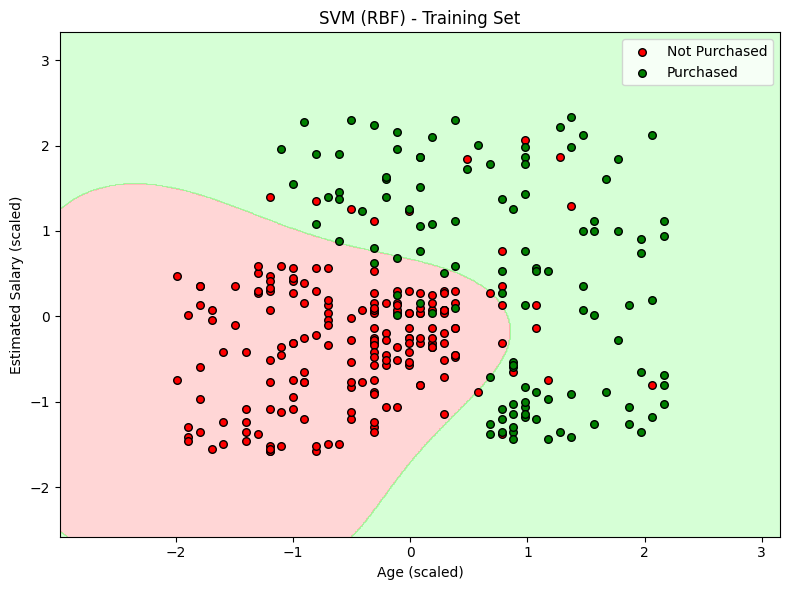

In [10]:
# Visualise the Decision Boundary on the TRAINING SET
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X_set, y_set, title):
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    # Predict the class for every point on the grid
    # np.c_ stacks the flattened X1 and X2 side-by-side to form (n, 2) input
    Z = classifier.predict(np.c_[X1.ravel(), X2.ravel()])
    Z = Z.reshape(X1.shape)  # reshape back to grid shape for plotting

    plt.figure(figsize=(8, 6))

    # Fill the background with colours based on predictions
    plt.contourf(X1, X2, Z, alpha=0.4,
                 cmap=ListedColormap(['#FF9999', '#99FF99']))

    # Plot the actual data points on top
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],  # Age (scaled)
            X_set[y_set == j, 1],  # Salary (scaled)
            c=['red', 'green'][i],
            label=['Not Purchased', 'Purchased'][i],
            edgecolors='black',
            s=30
        )

    plt.title(title)
    plt.xlabel('Age (scaled)')
    plt.ylabel('Estimated Salary (scaled)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X_train, y_train, 'SVM (RBF) - Training Set')

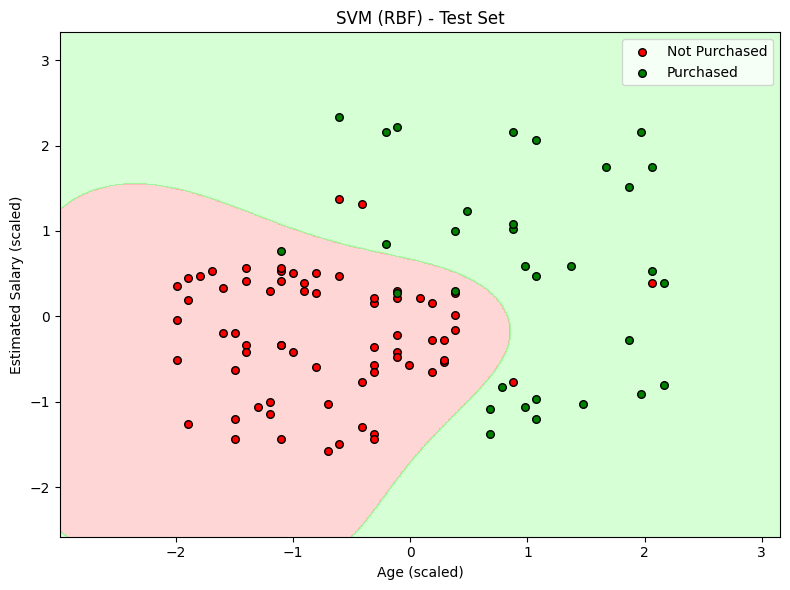

In [11]:
# Visualise the Decision Boundary on the TEST SET
plot_decision_boundary(X_test, y_test, 'SVM (RBF) - Test Set')

/tmp/ipykernel_799/2552399727.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


Text(0.5, 1.0, 'SVM (Test set)')

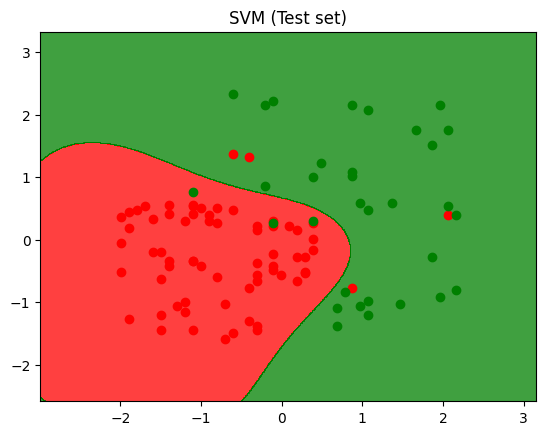

In [13]:
# Visualise the Test set results
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1,
              stop = X_set[:, 0].max() + 1,
              step = 0.01),
    np.arange(start = X_set[:, 1].min() - 1,
              stop = X_set[:, 1].max() + 1,
              step = 0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i),
        label = j
    )

plt.title('SVM (Test set)')